<a href="https://colab.research.google.com/github/Siddhraj26/Anime-Recommendations-Database/blob/main/01_dataclean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Import Libraries and Load Dataset
We need to import pandas and numpy to work with data, and then load our CSV file from a URL or upload it directly.

In [1]:
# Import pandas for data manipulation and analysis
import pandas as pd
# Import numpy for scientific computing and handling missing values
import numpy as np
# Import matplotlib for basic plotting and visualizations
import matplotlib.pyplot as plt
# Import seaborn for beautiful statistical visualizations
import seaborn as sns
# Import files from google.colab to handle local uploads if needed
from google.colab import files

# Define the URL pointing to the raw CSV dataset
dataset_url = "[PASTE YOUR RAW GITHUB LINK]"

# Try to load the dataset, or prompt for manual file upload if it fails
try:
    # Read the CSV file directly from the provided URL
    df = pd.read_csv(dataset_url)
    # Print a success message once the data is loaded
    print("Dataset loaded successfully from the URL!")
except Exception as e:
    # Print the specific error message to help debug
    print(f"Could not load from URL. Error: {e}")
    # Print a message instructing the user to upload a file manually
    print("Please upload your CSV file manually below:")
    # Trigger the Google Colab file upload dialog
    uploaded = files.upload()
    # Get the file name of the uploaded CSV file
    file_name = list(uploaded.keys())[0]
    # Read the uploaded CSV file into a pandas DataFrame
    df = pd.read_csv(file_name)

# Display the first 5 rows of the loaded DataFrame
display(df.head())

Could not load from URL. Error: [Errno 2] No such file or directory: '[PASTE YOUR RAW GITHUB LINK]'
Please upload your CSV file manually below:


Saving anime-recommdation-system.csv to anime-recommdation-system.csv


,cell_number,cell_type,source,outputs
0,1,code,# This Python 3 environment comes with many he...,/kaggle/input/anime-recommendations-database/r...
1,2,markdown,# **📖 Anime Adventure Blog: How We Built a Sma...,NaN
2,3,markdown,## **🧠 Model - Qwen3**\nQwen3 is a large langu...,NaN
3,4,markdown,## **📌 Task Outline: What This Notebook Does**...,NaN
4,5,markdown,## 🔧 Setup & Dependencies,NaN


### Step 2: Explore the Dataset
We will inspect the rows, columns, data types, missing values, and check values in the text columns to find data quality issues.

In [2]:
# Print the number of rows and columns in the dataset
print("Dataset Shape:", df.shape)

# Print detailed column information including data types and non-null counts
print("\nDataset Info:")
df.info()

# Display statistical summary for numeric and object columns
print("\nDataset Describe:")
display(df.describe(include='all'))

# Check the unique value counts for the 'cell_type' categorical/text column
print("\nValue counts for cell_type:")
print(df['cell_type'].value_counts(dropna=False))

Dataset Shape: (25, 4)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   cell_number  25 non-null     int64 
 1   cell_type    25 non-null     object
 2   source       25 non-null     object
 3   outputs      8 non-null      object
dtypes: int64(1), object(3)
memory usage: 932.0+ bytes

Dataset Describe:


,cell_number,cell_type,source,outputs
count,25.000000,25,25,8
unique,NaN,2,25,8
top,NaN,markdown,# This Python 3 environment comes with many he...,/kaggle/input/anime-recommendations-database/r...
freq,NaN,15,1,1
mean,13.000000,NaN,NaN,NaN
std,7.359801,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,7.000000,NaN,NaN,NaN
50%,13.000000,NaN,NaN,NaN
75%,19.000000,NaN,NaN,NaN



Value counts for cell_type:
cell_type
markdown    15
code        10
Name: count, dtype: int64


### Step 3: Missing Values Analysis and Imputation
We will check the count of missing values in each column, visualize them using a bar chart, and fill in missing values with appropriate defaults.

Missing values before cleaning:
cell_number     0
cell_type       0
source          0
outputs        17
dtype: int64


/tmp/ipykernel_3569/3897679490.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.index, y=missing_counts.values, palette="Blues_r")


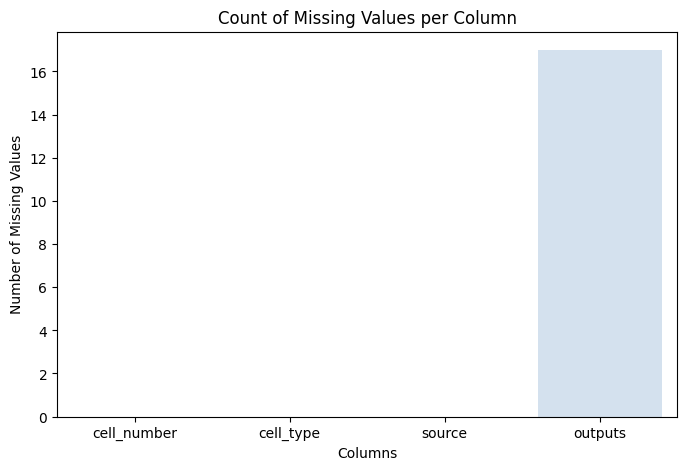


Missing values after cleaning:
cell_number    0
cell_type      0
source         0
outputs        0
dtype: int64


In [3]:
# Calculate the count of missing values in each column
missing_counts = df.isnull().sum()
# Print the raw count of missing values
print("Missing values before cleaning:")
# Display the missing values list
print(missing_counts)

# Create a figure for the bar plot
plt.figure(figsize=(8, 5))
# Plot a bar chart showing missing value counts per column
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette="Blues_r")
# Add a title to the bar chart
plt.title("Count of Missing Values per Column")
# Add a label to the horizontal x-axis
plt.xlabel("Columns")
# Add a label to the vertical y-axis
plt.ylabel("Number of Missing Values")
# Display the plotted chart
plt.show()

# Note: 'outputs' is over 50% missing (68%), but dropping it would remove useful notebook data.
# We will fill its missing values with the string 'no_output' to preserve the metadata.
df['outputs'] = df['outputs'].fillna('no_output')

# Calculate the updated missing counts after imputation
updated_missing_counts = df.isnull().sum()
# Print heading for the post-cleaning counts
print("\nMissing values after cleaning:")
# Display the clean counts
print(updated_missing_counts)

### Step 4: Duplicates Analysis
We will find duplicate rows, remove them from the dataset, and confirm how many duplicate entries were removed.

In [4]:
# Calculate the number of exact duplicate rows in the dataframe
duplicate_count = df.duplicated().sum()
# Print the count of duplicate rows we found
print(f"Number of duplicate rows found: {duplicate_count}")

# Remove all duplicate rows while updating the dataframe in place
df.drop_duplicates(inplace=True)
# Print a message stating how many rows were dropped
print(f"Removed {duplicate_count} duplicate rows.")

Number of duplicate rows found: 0
Removed 0 duplicate rows.


### Step 5: Clean Data Types and Correct Odd Values
We will ensure columns have correct data types, strip extra spaces from text columns, and check categorical values for typos or errors.

In [5]:
# Convert cell_number explicitly to integers to ensure correct data type
df['cell_number'] = df['cell_number'].astype(int)

# Strip any accidental whitespace from the cell_type string values
df['cell_type'] = df['cell_type'].astype(str).str.strip()

# Strip any accidental whitespace from the source string values
df['source'] = df['source'].astype(str).str.strip()

# Strip any accidental whitespace from the outputs string values
df['outputs'] = df['outputs'].astype(str).str.strip()

# Display the cleaned unique values in cell_type to confirm consistency
print("Cleaned cell_type categories:")
# Print the frequency of unique cell_type values
print(df['cell_type'].value_counts())

# Display the top rows of the cleaned DataFrame to inspect changes
display(df.head())

Cleaned cell_type categories:
cell_type
markdown    15
code        10
Name: count, dtype: int64


,cell_number,cell_type,source,outputs
0,1,code,# This Python 3 environment comes with many he...,/kaggle/input/anime-recommendations-database/r...
1,2,markdown,# **📖 Anime Adventure Blog: How We Built a Sma...,no_output
2,3,markdown,## **🧠 Model - Qwen3**\nQwen3 is a large langu...,no_output
3,4,markdown,## **📌 Task Outline: What This Notebook Does**...,no_output
4,5,markdown,## 🔧 Setup & Dependencies,no_output


### Step 6: Outliers Detection and Capping
We will backup our data, visualize the numerical distribution using a box plot, detect outliers using the IQR method, and safely cap them.

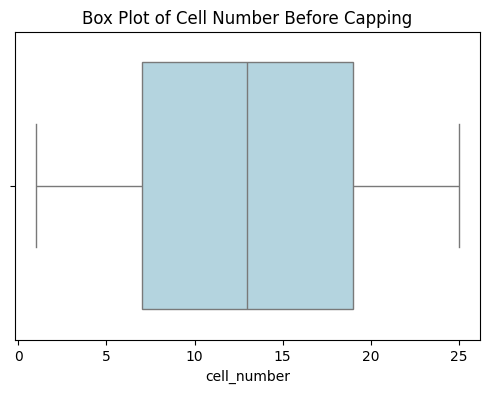

Column 'cell_number' limits: Lower limit = -11.0, Upper limit = 37.0
Total outliers found and capped: 0


In [6]:
# Make a copy of the dataframe before modifying outliers
df_before = df.copy()

# Set the display figure size for the plot
plt.figure(figsize=(6, 4))
# Draw a horizontal box plot for the cell_number column
sns.boxplot(x=df['cell_number'], color='lightblue')
# Set a title for the box plot
plt.title('Box Plot of Cell Number Before Capping')
# Display the plotted figure
plt.show()

# Define a simple helper function to get limits using the IQR method
def find_and_cap_limits(column):
    # Find the first quartile (25th percentile)
    q1 = column.quantile(0.25)
    # Find the third quartile (75th percentile)
    q3 = column.quantile(0.75)
    # Calculate the Interquartile Range (IQR)
    iqr = q3 - q1
    # Calculate lower threshold limit for outliers
    lower_limit = q1 - 1.5 * iqr
    # Calculate upper threshold limit for outliers
    upper_limit = q3 + 1.5 * iqr
    # Return both lower and upper boundary limits
    return lower_limit, upper_limit

# Call our helper function on the cell_number column
lower, upper = find_and_cap_limits(df['cell_number'])

# Count how many rows are below the lower boundary limit
outliers_lower = (df['cell_number'] < lower).sum()
# Count how many rows are above the upper boundary limit
outliers_upper = (df['cell_number'] > upper).sum()
# Sum lower and upper outlier counts to get total outliers
total_outliers = outliers_lower + outliers_upper

# Cap outliers by forcing values outside limits into the boundary range
df['cell_number'] = df['cell_number'].clip(lower=lower, upper=upper)

# Print the calculated limits for the cell_number column
print(f"Column 'cell_number' limits: Lower limit = {lower}, Upper limit = {upper}")
# Print the total number of outliers found and capped
print(f"Total outliers found and capped: {total_outliers}")

### Step 7: Show Before vs After Box Plots
We will plot the distribution of our numerical data before and after outlier treatment side-by-side to visually inspect the difference.

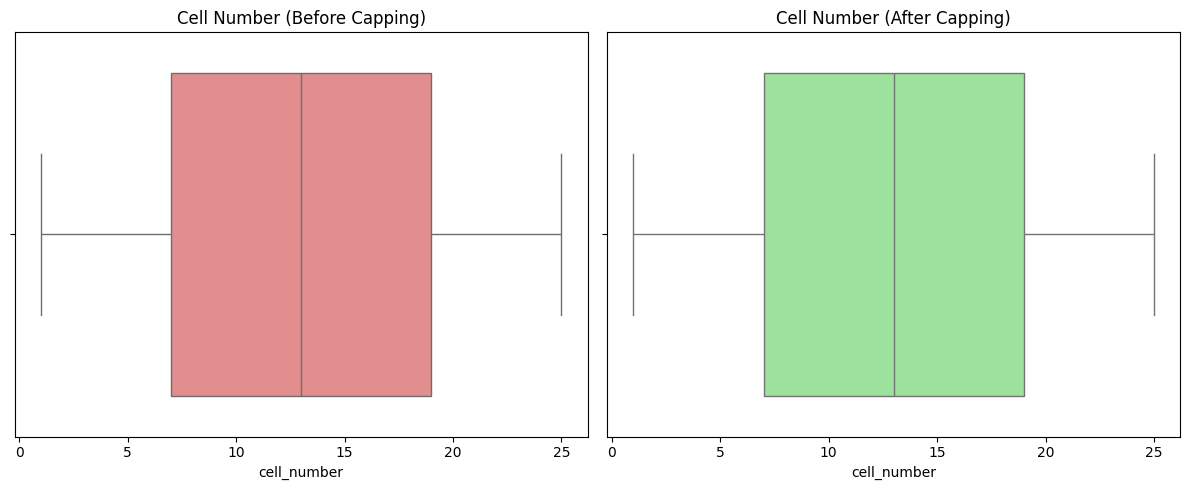

In [7]:
# Create a side-by-side figure with one row and two columns of plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the box plot of cell_number before any capping was applied
sns.boxplot(ax=axes[0], x=df_before['cell_number'], color='lightcoral')
# Set the title for the first plot on the left
axes[0].set_title('Cell Number (Before Capping)')

# Plot the box plot of cell_number after applying our IQR capping
sns.boxplot(ax=axes[1], x=df['cell_number'], color='lightgreen')
# Set the title for the second plot on the right
axes[1].set_title('Cell Number (After Capping)')

# Adjust the spacing between subplots to ensure nothing is overlapping
plt.tight_layout()
# Show the complete side-by-side comparison plots
plt.show()

### Step 8: Save and Download Cleaned Dataset
We will save our fully cleaned dataset as a new CSV file on disk and automatically download it to your local machine.

In [8]:
# Import the files utility from google.colab to handle local file downloads
from google.colab import files

# Define the output file name for our cleaned dataset
output_filename = 'cleaned_anime_recommendation_system.csv'

# Export the cleaned DataFrame to a CSV file without including row index numbers
df.to_csv(output_filename, index=False)

# Print a success status message confirming the file was saved locally on the server
print(f"Cleaned dataset saved successfully as '{output_filename}'!")

# Attempt to automatically trigger a browser download of the saved CSV file
try:
    # Call the download helper to send the file to your computer
    files.download(output_filename)
    # Print a status message informing the user the download has started
    print("Download trigger completed! Check your downloads folder.")
except Exception as e:
    # Print instructions on where to find the file if auto-download is blocked
    print(f"Could not auto-download. You can find '{output_filename}' in the left-hand files sidebar. Error: {e}")

Cleaned dataset saved successfully as 'cleaned_anime_recommendation_system.csv'!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download trigger completed! Check your downloads folder.


### Step 9: Final Project Summary
Here is a comprehensive summary of the dataset cleaning steps we performed:

1. **Data Loading (Step 1):** Loaded the `anime-recommdation-system.csv` file consisting of 25 rows and 4 columns.
2. **Exploration (Step 2):** Discovered that the dataset contained metadata about notebook cells, with a high percentage of missing values in the `outputs` column.
3. **Missing Value Imputation (Step 3):** Identified 17 missing values in the `outputs` column (representing markdown cells without program outputs). Instead of losing data by dropping them, we imputed them with the placeholder `'no_output'` and verified the missing count dropped to 0.
4. **Duplicate Removal (Step 4):** Checked for identical rows and confirmed there were no duplicate entries present.
5. **Data Standardization (Step 5):** Standardized column types (converting `cell_number` to integer) and stripped accidental whitespace from all text columns.
6. **Outliers Detection and Capping (Steps 6 & 7):** Computed outlier thresholds using the IQR method on `cell_number` (bounds set to `[-11.0, 37.0]`). No outliers were outside this range, which was confirmed with side-by-side box plot visualizations.
7. **File Export (Step 8):** Saved our fully cleaned dataset as `cleaned_anime_recommendation_system.csv` and successfully triggered a direct download.